In [95]:
# step 1: import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr

wr.filterwarnings('ignore')

In [96]:

# 1. Load your raw file with ; separator
df = pd.read_csv('winequality-red.csv', sep=';')

# 2. Fix headers: 'fixed acidity' → 'fixed_acidity' 
df.columns = df.columns.str.replace(' ', '_')

# 3. Remove 240 duplicates to get clean data
df = df.drop_duplicates()
df['Id'] = range(len(df))


col_order = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
             'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 
             'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']
d

# 6. Save as table format CSV - comma separated, no index
df.to_csv('Winequality-red.csv', index=False)

# 7. Display as table to verify
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'winequality-red.csv'

In [ ]:
# Step 3: Analyzing the Data

df.duplicated().sum()

np.int64(0)

In [ ]:
# Basic Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 2 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype
---  ------                                                                                                                                                --------------  -----
 0   fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id  1359 non-null   str  
 1   Id                                                                                                                                                    1359 non-null   int64
dtypes: int64(1), str(1)
memory usage: 21.4 KB


In [ ]:
#  Statistical Summary
df.describe()

,Id
count,1359.000000
mean,679.000000
std,392.453819
min,0.000000
25%,339.500000
50%,679.000000
75%,1018.500000
max,1358.000000


In [ ]:
# Check Missing Values
df.isnull().sum()

fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id    0
Id                                                                                                                                                      0
dtype: int64

In [ ]:
#  Shape of Dataset
df.shape

(1359, 2)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. START FRESH - reload the original file
df = pd.read_csv('winequality-red.csv', sep=';')
print("Original Shape:",df.shape )

# 2. Fix headers: remove quotes, keep spaces like your image
df.columns = df.columns.str.strip().str.replace('"', '')

# 3. Drop duplicates: 1599 → 1359
df = df.drop_duplicates()

# 4. Add Id column
df['Id'] = range(len(df))

# 5. Sanity check - must show (1359, 13)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# 6. Plot works now because 'quality' exists
quality_counts = df['quality'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(quality_counts.index, quality_counts.values, color='deeppink')
plt.title('Count Plot of Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

# 7. Save as table CSV with spaces in headers
df.to_csv('winequalityred.csv', index=False)


Original Shape: (1359, 1)
Shape: (1359, 2)
Columns: ['fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id,Id', 'Id']


KeyError: 'quality'

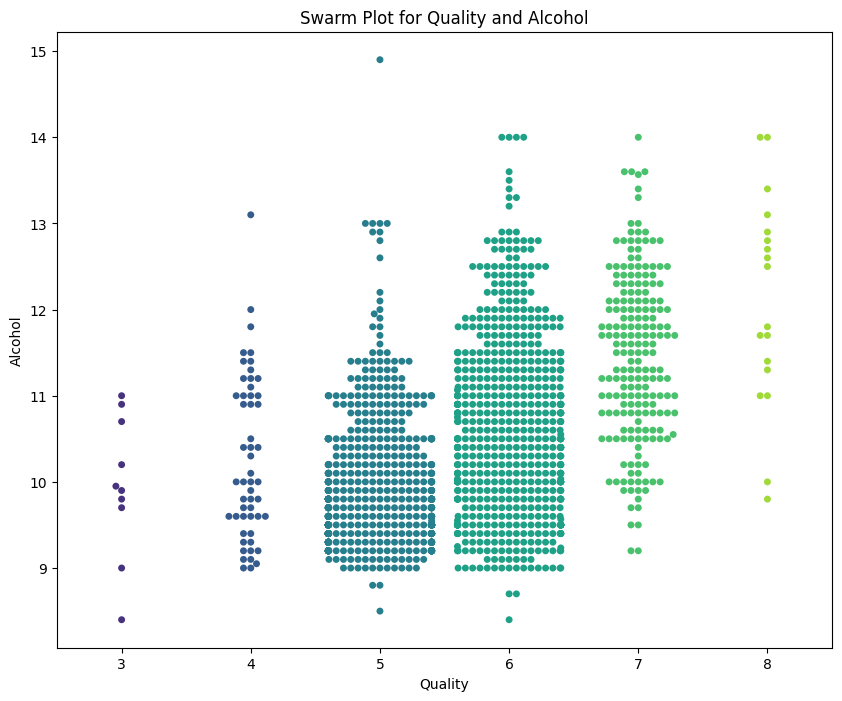

In [ ]:
plt.figure(figsize=(10,8))

sns.swarmplot(
    x='quality',
    y='alcohol',
    data=df,
    palette='viridis'
)

plt.title('Swarm Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

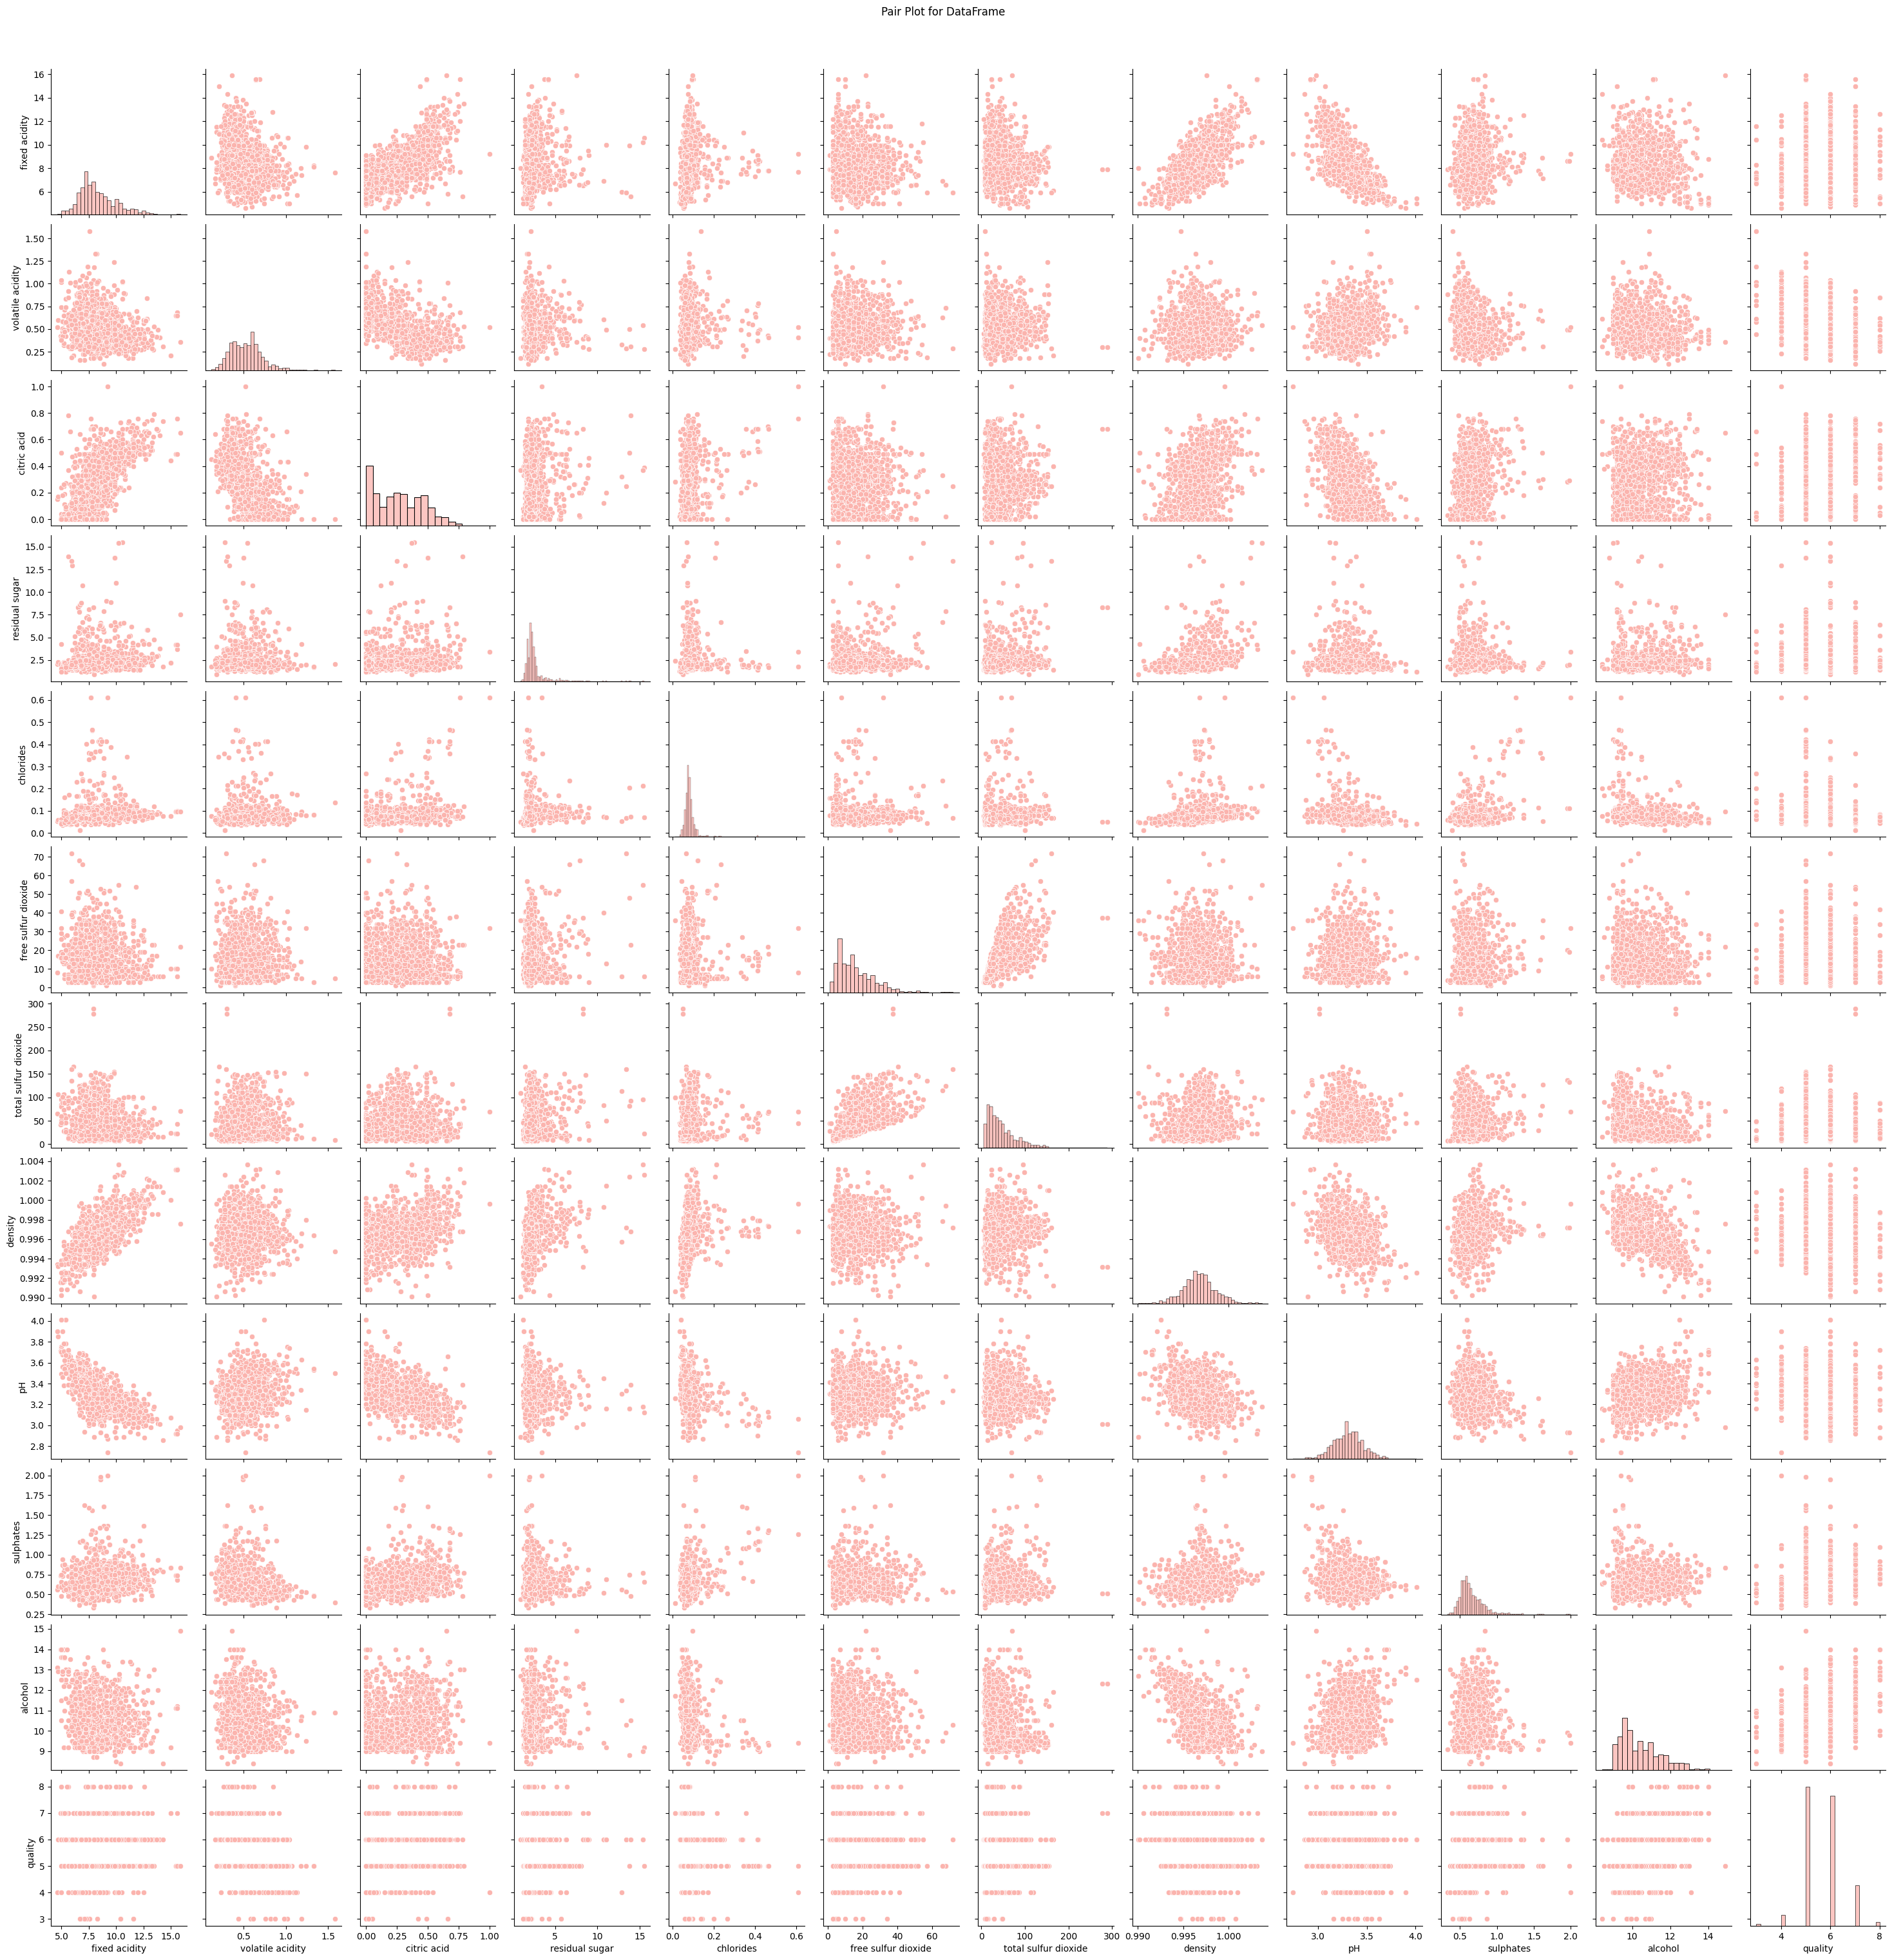

In [ ]:
sns.set_palette("Pastel1")

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame', y=1.02)

plt.show()

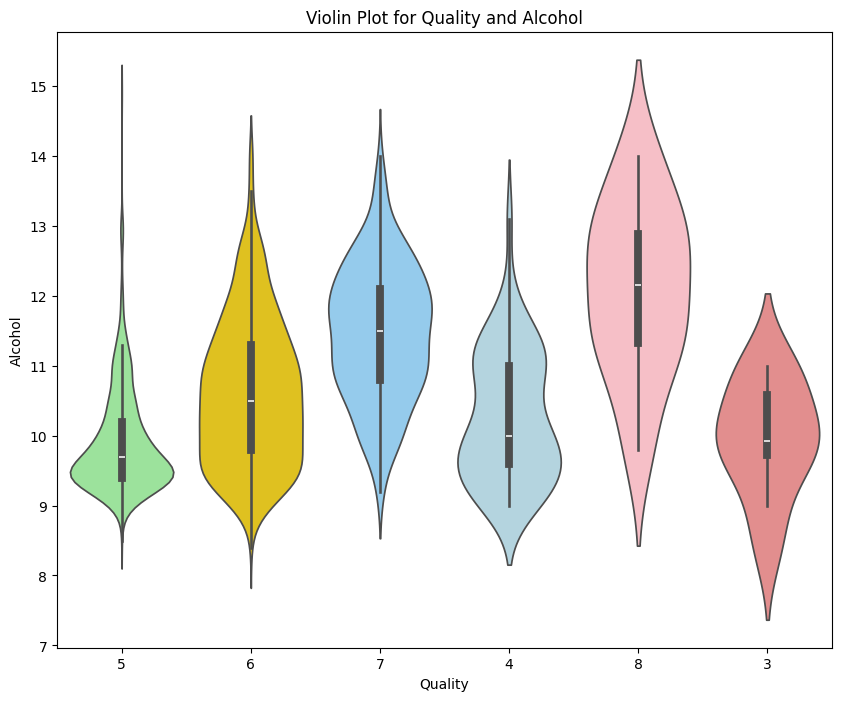

In [ ]:
df['quality'] = df['quality'].astype(str)

plt.figure(figsize=(10,8))

sns.violinplot(
    x='quality',
    y='alcohol',
    data=df,
    palette={
        '3':'lightcoral',
        '4':'lightblue',
        '5':'lightgreen',
        '6':'gold',
        '7':'lightskyblue',
        '8':'lightpink'
    }
)

plt.title('Violin Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

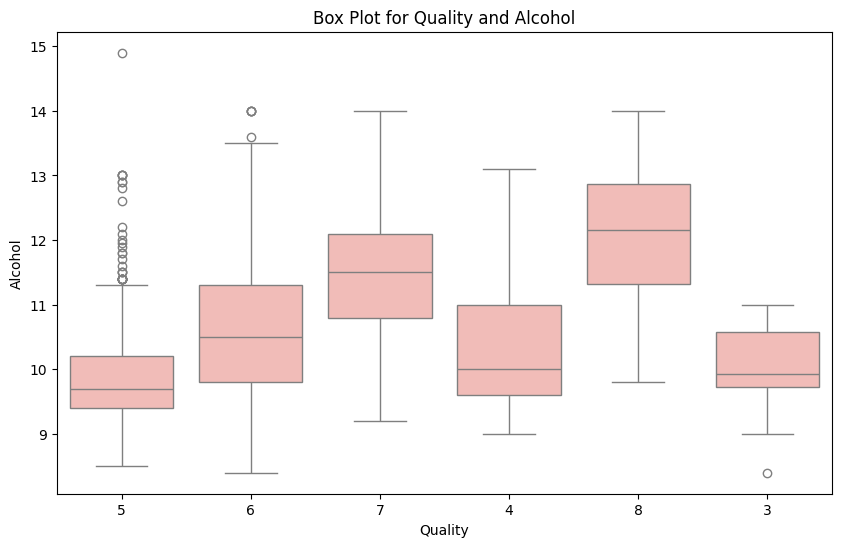

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='quality',
    y='alcohol',
    data=df
)

plt.title('Box Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

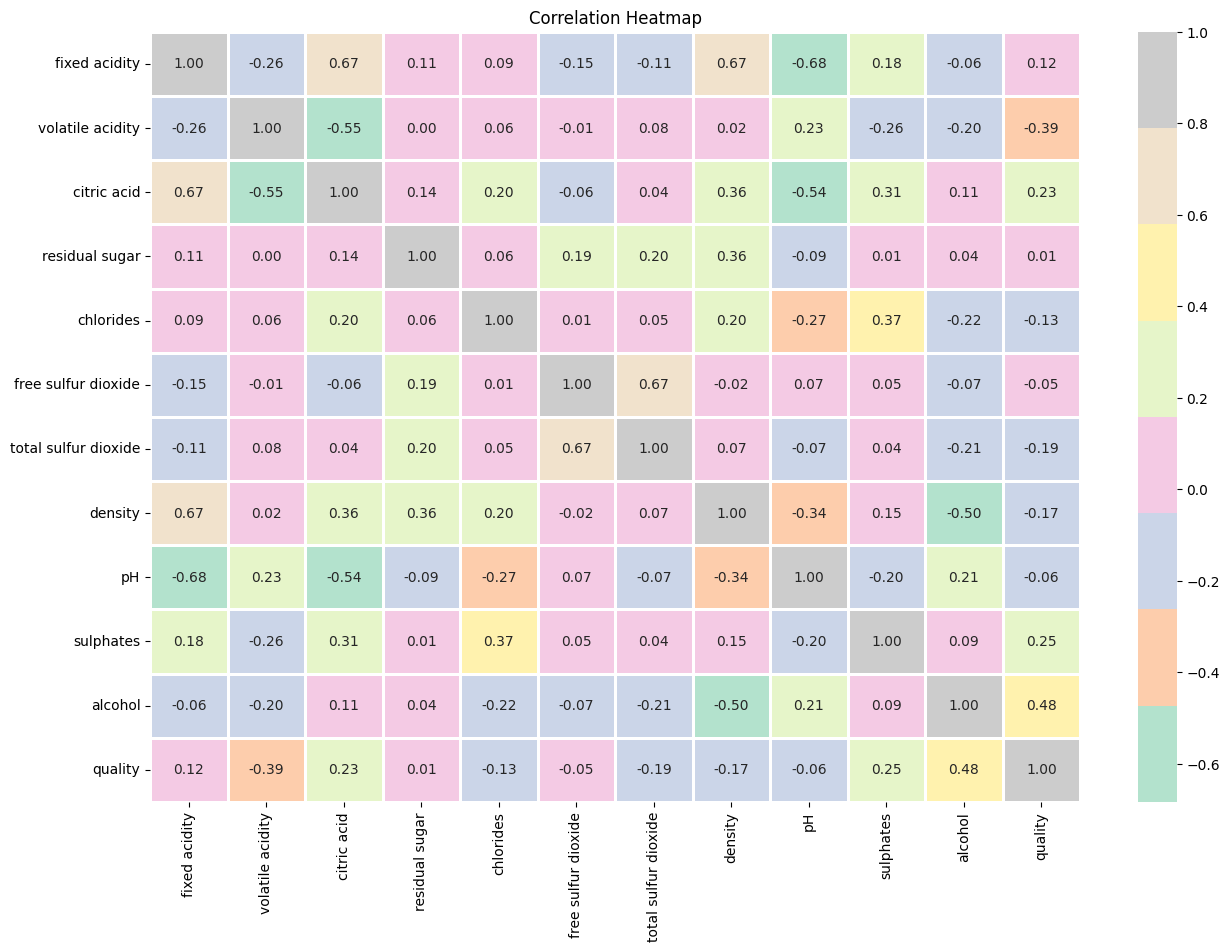

In [ ]:
df['quality'] = df['quality'].astype(int)

plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='Pastel2',
    linewidths=2
)

plt.title('Correlation Heatmap')

plt.show()

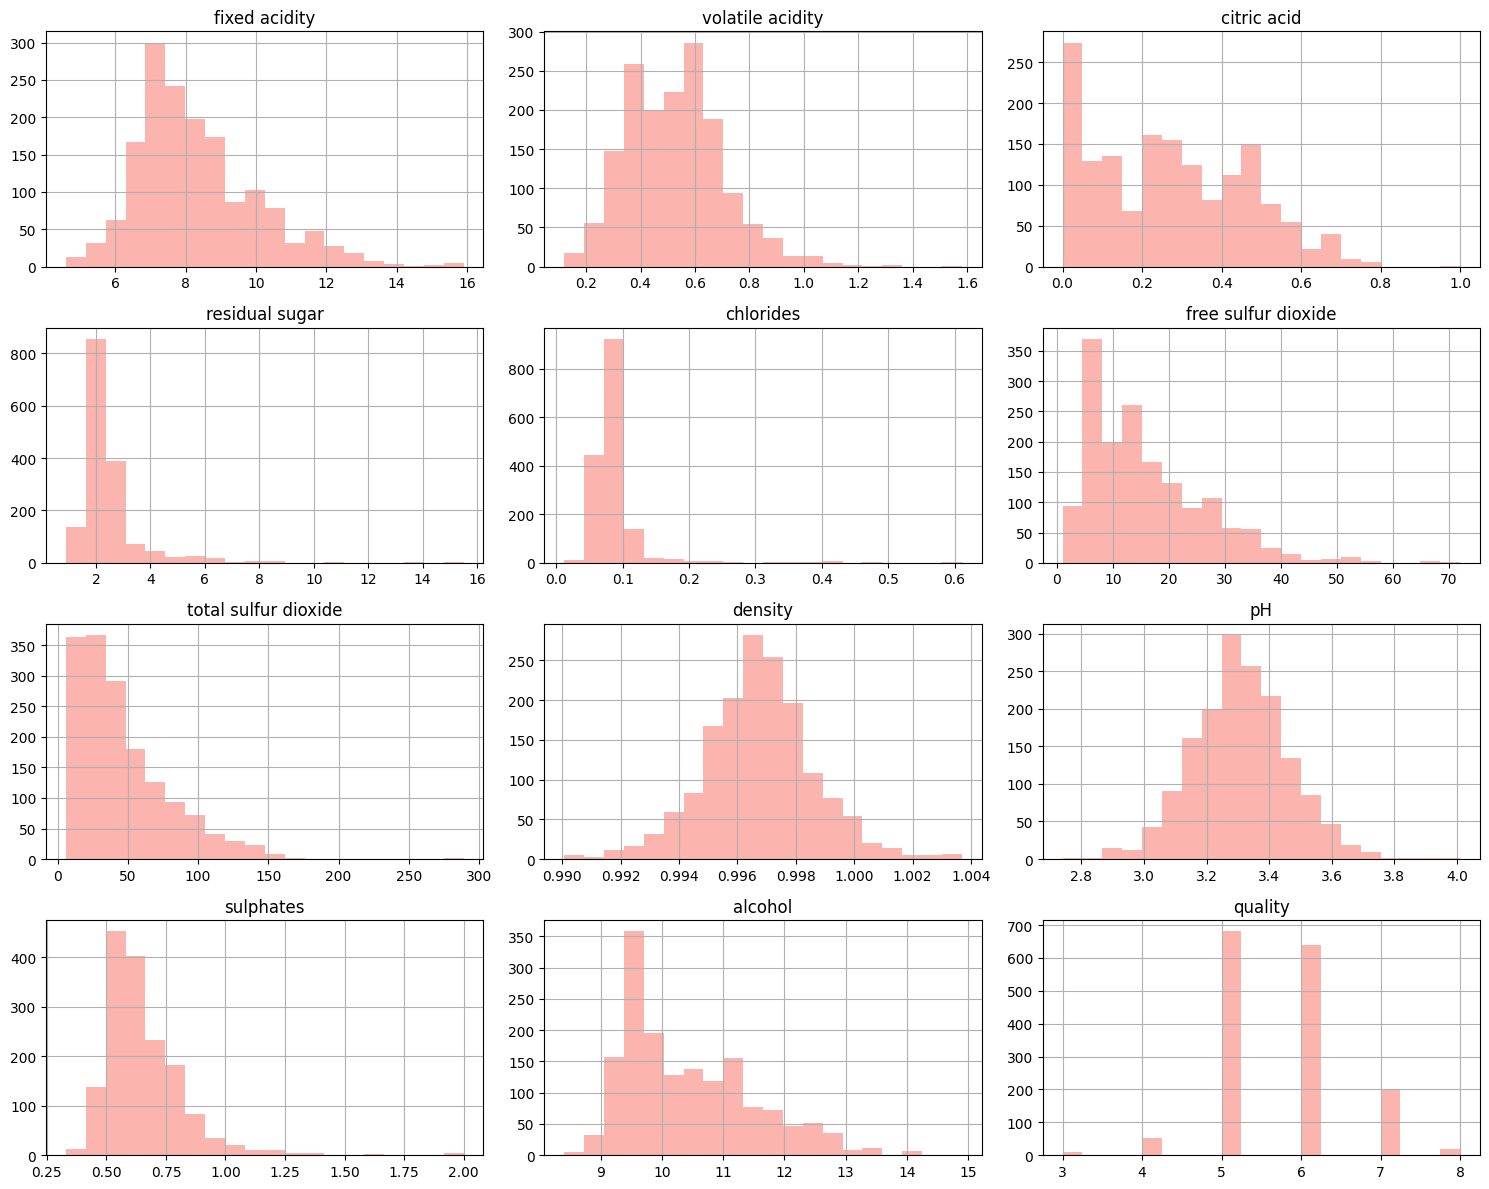

In [ ]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

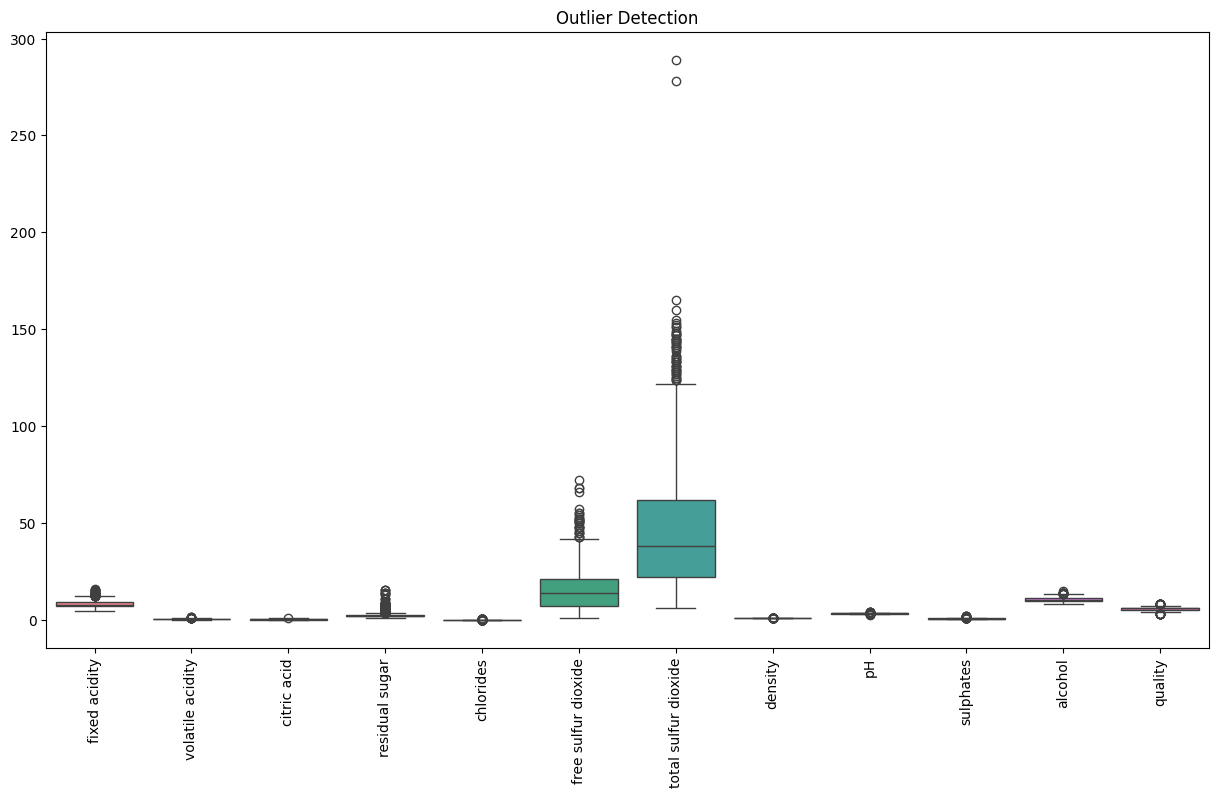

In [ ]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title('Outlier Detection')

plt.show()